<a href="https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap01/1_1_BackgroundMathematics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction to deep learning - TP1**

L’objectif de ce notebook Python est de s’assurer que vous savez utiliser CoLab et de vous familiariser avec certains concepts mathématiques de base dont vous aurez besoin pour commencer à travailler sur les sujets de l’apprentissage profond.

À différents endroits, vous verrez la mention «A COMPLETER». Suivez les instructions indiquées à ces endroits.
Si vous n’arrivez pas à comprendre ce qui est demandé ou comment compléter une section, n’hésitez pas à poser des questions pendant les séances de TP.

In [48]:
# Imports math library
# Imports plotting library
import numpy as np
import matplotlib.pyplot as plt

**Application linéaire**<br> 
On considère la fonction $$h(x) = \sigma(w^T x - b)$$ 
définie sur le plan 2-dimensionnel, où $w\in\mathbb{R}^2$ et $b\in\mathbb{R}$ sont les paramètres donées, et $\sigma$ est une fonction réelle définie par $\sigma(z) = z$ si $z\geq 0$ et sinon $\sigma(z)=0$. 

Pour un vecteur d'entrée $x=(x_{1}, x_{2})^T$, la valeur de la fonction $h(x)$ s'écrit :

\begin{equation}h(x)= \sigma(w_1 x_1 + w_2 x_2 -b).\end{equation}



Représentation des paramètres $w$ et $b$

In [49]:
w = np.array([2, 3]) # we use a numpy array to represent a vector on the 2D plan
b = 0 # scalar 

# Plot the random points x on the 2D plan. 
# Each point x will be colored according the h(x) function value
def plot_h_2d( X, Y):  
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    Ymax = max(abs(Y)) # get the maximal value of |h(x)| 
    for i in range(X.shape[0]):
        if Y[i] > 0:
            color = 'red'
            alpha_value = Y[i]/Ymax
        else:
            color = 'blue'
            alpha_value = 1 
        ax.scatter(X[i,0],X[i,1], alpha=alpha_value, \
                 marker='o', facecolors='none', edgecolors=color)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    return fig, ax

# Plot the random points x on the 2D plan. 
# Each point x will be colored according the h(x) function value.
# At the same time, the point x_star on H(w,b) closest to x will be shown 
#   (when |x| is large enough, to limit the number of x_star to be plotted)
def plot2_h_2d( X, Y, X_star):  
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    Ymax = max(abs(Y)) # get the maximal value of |h(x)| 
    for i in range(X.shape[0]):
        if Y[i] > 0:
            color = 'red'
            alpha_value = Y[i]/Ymax
        else:
            color = 'blue'
            alpha_value = 1 
        ax.scatter(X[i,0],X[i,1], alpha=alpha_value, \
                 marker='o', facecolors='none', edgecolors=color)
    for i in range(X_star.shape[0]):
        ax.scatter(X_star[i,0],X_star[i,1], alpha=1, \
                 marker='x', color='k')
    ax.set_xlabel('x_1'); ax.set_ylabel('x_2')
    return fig, ax


In [50]:


def sigma_value(z): 
    # -- A COMPLETER -- 
    # replace the line below to compute the value sigma(z)     
    value = z 
    if z >= 0:
        value = z
    else: 
        value = 0
    return value

# Define a linear function with just one input, x
def function_h(x, w, b):
    # -- A COMPLETER -- 
    # replace the line below to compute the value y = h(x) 
    y = x
    wtx = w.dot(x) 
    y = sigma_value( wtx - b)
    return y

x = np.array([-0.5, -2])
print('h(%.2f,%.2f) = '%(x[0],x[1]), function_h(x, w, b))

x = np.array([-0.5, 2])
print('h(%.2f,%.2f) = '%(x[0],x[1]), function_h(x, w, b))




h(-0.50,-2.00) =  0
h(-0.50,2.00) =  5.0


h(0.04,1.04) =  3.210789099192336
h(1.06,-0.95) =  0
h(0.71,-0.46) =  0.06192576602177735
h(1.45,-0.31) =  1.9756020683032698
h(1.03,-1.06) =  0
h(0.75,-1.40) =  0
h(0.08,-1.65) =  0
h(-0.17,-0.82) =  0
h(-1.00,0.21) =  0


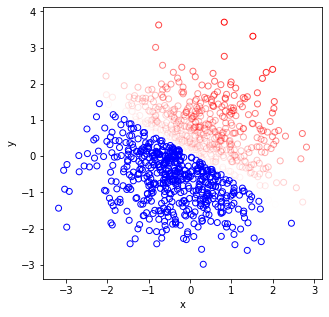

In [51]:

# Generate N points on the 2D plan randomly
# Set the random seed of np.random to a fixed value, say, seed=3 
fixed_seed = 3
np.random.seed( fixed_seed )
N = 1000
X = np.random.normal(size=[N, 2], scale=1)

# For each row x_i in X, compute the function value h(x_i)
Y = []
for i in range(X.shape[0]): 
    x_i = X[i,:]
    y_i = function_h(x_i, w, b)
    Y.append(y_i)
    if i > N-10: 
        print('h(%.2f,%.2f) = '%(x_i[0],x_i[1]), function_h(x_i, w, b))
# vectorize the python list Y into a numpy array (a vector)
Y = np.array(Y) # this facilitates operations with absolute values (abs), etc

fig, ax = plot_h_2d(X,Y)


h(0.04,1.04) =  3.210789099192336
h(1.06,-0.95) =  0
h(0.71,-0.46) =  0.06192576602177735
h(1.45,-0.31) =  1.9756020683032698
h(1.03,-1.06) =  0
h(0.75,-1.40) =  0
h(0.08,-1.65) =  0
h(-0.17,-0.82) =  0
h(-1.00,0.21) =  0


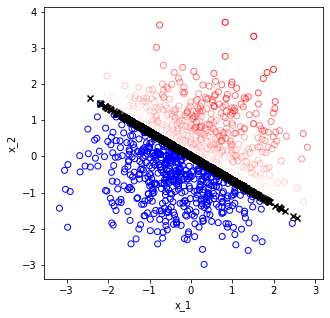

In [52]:
def compute_xstar(x, w, b): 
    # solution 
    # xstar = x - w * (w.dot(x) - b)/(np.linalg.norm(w)**2)
    xstar = x - w * (w.dot(x) - b)/(w**2).sum()
    return xstar 

# For each row x_i in X, compute the function value h(x_i)
Y = [] ; X_star = []
for i in range(X.shape[0]): 
    x_i = X[i,:]
    y_i = function_h(x_i, w, b)
    Y.append(y_i) 
    if np.linalg.norm(x_i) > 0.8:
        x_star = compute_xstar(x_i, w, b)
        X_star.append( x_star )
    if i > N-10: 
        print('h(%.2f,%.2f) = '%(x_i[0],x_i[1]), function_h(x_i, w, b))

# Vectorize the python list Y into a numpy array (a vector) to facilitate the plot function here.
Y = np.array(Y) 
X_star = np.array(X_star)

fig, ax = plot2_h_2d(X,Y, X_star)